# Final Project - Part 2: Evaluation and Analysis

This notebook loads the results produced by `01_debate_system.ipynb` and computes all the
metrics required in Phase 3 of the assignment, plus the plots.

**System-level metrics:**
- Overall accuracy - % of problems where the system's final answer is correct
- Improvement rate - % of problems where refinement improved the initial answers
- Consensus rate - % of problems where all 3 solvers converged to the same refined answer
- Judge accuracy - when the solvers disagree, does the judge pick a correct one?

**Baselines to compare against:**
- Single-LLM: just ask each model once
- Simple voting: 3 independent solutions, take the majority answer

In [23]:
import json
import os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = "results/debate_results.json"
BASELINE_PATH = "results/baseline_results.json"
os.makedirs("plots", exist_ok=True)

with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)
with open(BASELINE_PATH, "r", encoding="utf-8") as f:
    baselines = json.load(f)

AGENTS = ["openai", "openai-35", "claude", "claude-haiku"]
AGENT_MODELS = {"openai": "gpt-4.1-mini", "openai-35": "gpt-3.5-turbo",
                "claude": "claude-sonnet-4-5", "claude-haiku": "claude-haiku-4-5"}
print(f"{len(results)} debate results, {len(baselines)} baseline results")

25 debate results, 25 baseline results


### Plot style

Using the Okabe-Ito palette because it is colorblind-safe, plus some small matplotlib cleanups
(no top/right spines, light y-grid) so the plots are readable.

In [24]:
BLUE = "#0072B2"     # main color - the debate system
ORANGE = "#E69F00"   # contrast - baselines
GREEN = "#009E73"
GRAY = "#999999"
RED = "#D55E00"

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
    "font.size": 11,
})


def save(fig, name):
    fig.savefig(f"plots/{name}", dpi=150, bbox_inches="tight")
    print(f"saved plots/{name}")

## Flatten the results into a DataFrame

In [25]:
rows = []
for pid, r in results.items():
    n_initial_correct = sum(s["correct"] for s in r["solutions"].values())
    n_refined_correct = sum(x["correct"] for x in r["refinements"].values())
    rows.append({
        "id": pid,
        "category": r["category"],
        "judge_model": r["judge_model"],
        "final_correct": r["final_correct"],
        "voting_correct": r["voting_baseline"]["correct"],
        "n_initial_correct": n_initial_correct,
        "n_refined_correct": n_refined_correct,
        "initial_all_same": r["voting_baseline"]["all_same"],
        "refined_all_same": r["refined_consensus"]["all_same"],
        "judge_confidence": r["verdict"]["confidence"],
        "winner": r["verdict"]["winner"],
        "winner_model": r["solver_models"][r["verdict"]["winner"]],
        "time_seconds": r["time_seconds"],
    })

df = pd.DataFrame(rows).set_index("id")
df.head(10)

,category,judge_model,final_correct,voting_correct,n_initial_correct,n_refined_correct,initial_all_same,refined_all_same,judge_confidence,winner,winner_model,time_seconds
id,,,,,,,,,,,,
prob_01,probability_expectation,claude-haiku,True,True,3,3,False,True,0.85,solver_2,openai,74.8
opt_01,optimization,claude,True,True,2,1,False,False,0.95,solver_1,claude-haiku,68.3
opt_02,optimization,claude-haiku,True,False,3,3,True,True,0.95,solver_1,claude,51.0
opt_03,optimization,claude,True,True,2,3,False,True,0.95,solver_1,claude-haiku,57.4
opt_04,optimization,claude,True,True,2,3,False,True,0.95,solver_1,claude-haiku,48.0
opt_05,optimization,claude-haiku,True,True,2,3,False,True,0.95,solver_1,claude,99.9
prob_02,probability_expectation,claude-haiku,True,True,2,2,False,False,0.95,solver_1,claude,75.8
prob_03,probability_expectation,claude-haiku,True,True,3,3,True,True,0.95,solver_1,claude,65.2
prob_04,probability_expectation,claude,True,True,2,2,False,True,0.95,solver_1,claude-haiku,54.0


## System-level metrics

In [26]:
n = len(df)

overall_accuracy = df["final_correct"].mean()
voting_accuracy = df["voting_correct"].mean()
consensus_rate = df["refined_all_same"].mean()

# improvement rate: problems where the refined answers are strictly better than the initial ones
improved = (df["n_refined_correct"] > df["n_initial_correct"]).sum()
unchanged = (df["n_refined_correct"] == df["n_initial_correct"]).sum()
worsened = (df["n_refined_correct"] < df["n_initial_correct"]).sum()
improvement_rate = improved / n

# judge accuracy: only counts problems where the solvers actually disagreed after refinement
disagreements = df[~df["refined_all_same"]]
judge_acc_on_disagreement = disagreements["final_correct"].mean() if len(disagreements) else float("nan")
# fairer version: among disagreements where at least one refined answer was correct,
# did the judge manage to pick a correct one?
winnable = disagreements[disagreements["n_refined_correct"] > 0]
judge_acc_winnable = winnable["final_correct"].mean() if len(winnable) else float("nan")

single_acc = {m: pd.Series({pid: baselines[pid][m]["correct"] for pid in baselines}).mean() for m in AGENTS}

print(f"problems: {n}")
print(f"overall accuracy (debate system): {overall_accuracy:.0%}")
print(f"voting baseline accuracy:          {voting_accuracy:.0%}")
for m in AGENTS:
    print(f"single {m:<12} accuracy:       {single_acc[m]:.0%}")
print()
print(f"improvement rate: {improvement_rate:.0%} ({improved} improved, {unchanged} unchanged, {worsened} worsened)")
print(f"consensus rate (refined answers): {consensus_rate:.0%}")
print(f"solver disagreements after refinement: {len(disagreements)}")
print(f"judge accuracy on disagreements: {judge_acc_on_disagreement:.0%}" if len(disagreements) else "no disagreements")
if len(winnable):
    print(f"judge accuracy when a correct option existed: {judge_acc_winnable:.0%} ({len(winnable)} such problems)")
print(f"\navg time per problem: {df['time_seconds'].mean():.0f}s")

problems: 25
overall accuracy (debate system): 100%
voting baseline accuracy:          96%
single openai       accuracy:       96%
single openai-35    accuracy:       16%
single claude       accuracy:       96%
single claude-haiku accuracy:       100%

improvement rate: 48% (12 improved, 12 unchanged, 1 worsened)
consensus rate (refined answers): 60%
solver disagreements after refinement: 10
judge accuracy on disagreements: 100%
judge accuracy when a correct option existed: 100% (10 such problems)

avg time per problem: 67s


In [27]:
# save the metrics table for the README
summary = {
    "debate_system": overall_accuracy,
    "voting_baseline": voting_accuracy,
    **{f"single_{m}": single_acc[m] for m in AGENTS},
    "improvement_rate": improvement_rate,
    "consensus_rate": consensus_rate,
    "judge_accuracy_on_disagreements": judge_acc_on_disagreement,
}
pd.Series(summary, name="value").to_csv("results/metrics_summary.csv")
pd.Series(summary, name="value").round(3)

debate_system                      1.00
voting_baseline                    0.96
single_openai                      0.96
single_openai-35                   0.16
single_claude                      0.96
single_claude-haiku                1.00
improvement_rate                   0.48
consensus_rate                     0.60
judge_accuracy_on_disagreements    1.00
Name: value, dtype: float64

## Plot 1: accuracy - debate system vs all baselines

The main result of the whole project in one picture.

saved plots/accuracy_comparison.png


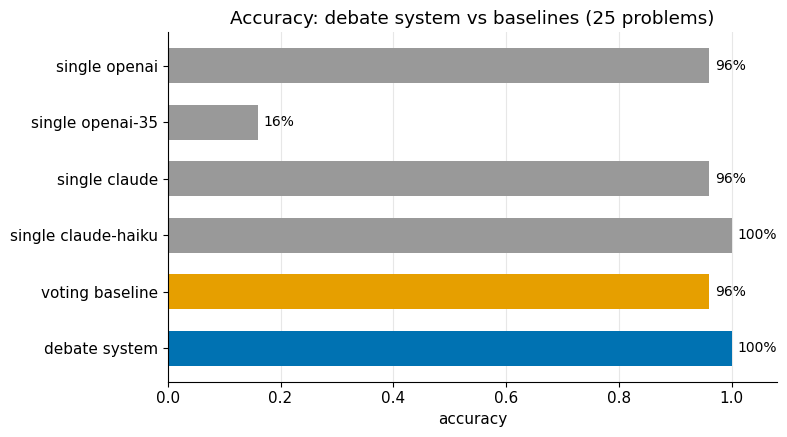

In [28]:
methods = [f"single {m}" for m in AGENTS] + ["voting baseline", "debate system"]
values = [single_acc[m] for m in AGENTS] + [voting_accuracy, overall_accuracy]
colors = [GRAY] * 4 + [ORANGE, BLUE]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(methods, values, color=colors, height=0.62)
for b, v in zip(bars, values):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.0%}", va="center", fontsize=10)
ax.set_xlim(0, 1.08)
ax.set_xlabel("accuracy")
ax.set_title(f"Accuracy: debate system vs baselines ({n} problems)")
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)
ax.invert_yaxis()
fig.tight_layout()
save(fig, "accuracy_comparison.png")
plt.show()

## Plot 2: accuracy by problem category

saved plots/accuracy_by_category.png


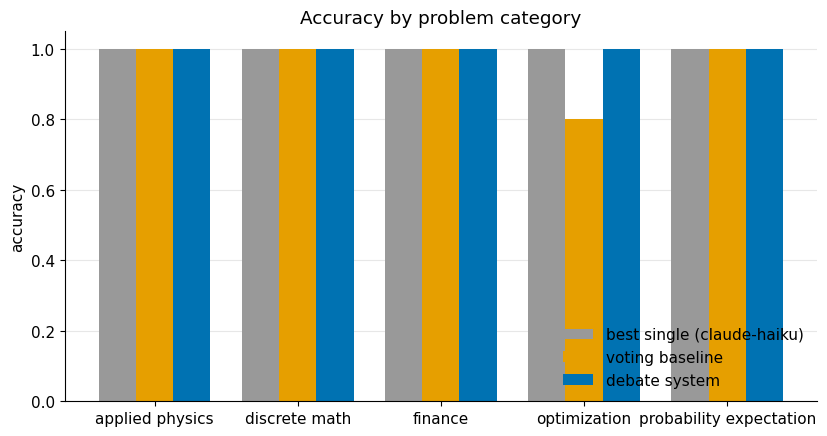

In [29]:
best_single_model = max(single_acc, key=single_acc.get)
cats = sorted(df["category"].unique())

cat_debate, cat_voting, cat_single = [], [], []
for c in cats:
    ids = df[df["category"] == c].index
    cat_debate.append(df.loc[ids, "final_correct"].mean())
    cat_voting.append(df.loc[ids, "voting_correct"].mean())
    cat_single.append(pd.Series({pid: baselines[pid][best_single_model]["correct"] for pid in ids}).mean())

x = range(len(cats))
w = 0.26
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar([i - w for i in x], cat_single, w, label=f"best single ({best_single_model})", color=GRAY)
ax.bar(x, cat_voting, w, label="voting baseline", color=ORANGE)
ax.bar([i + w for i in x], cat_debate, w, label="debate system", color=BLUE)
ax.set_xticks(list(x))
ax.set_xticklabels([c.replace("_", " ") for c in cats])
ax.set_ylim(0, 1.05)
ax.set_ylabel("accuracy")
ax.set_title("Accuracy by problem category")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
save(fig, "accuracy_by_category.png")
plt.show()

## Plot 3: what did refinement actually do?

Left: average number of correct solvers before and after the peer review + refinement round,
and the final system accuracy on top of that.
Right: per-problem effect of refinement (did the number of correct solvers go up, stay, or go down).

saved plots/refinement_effect.png


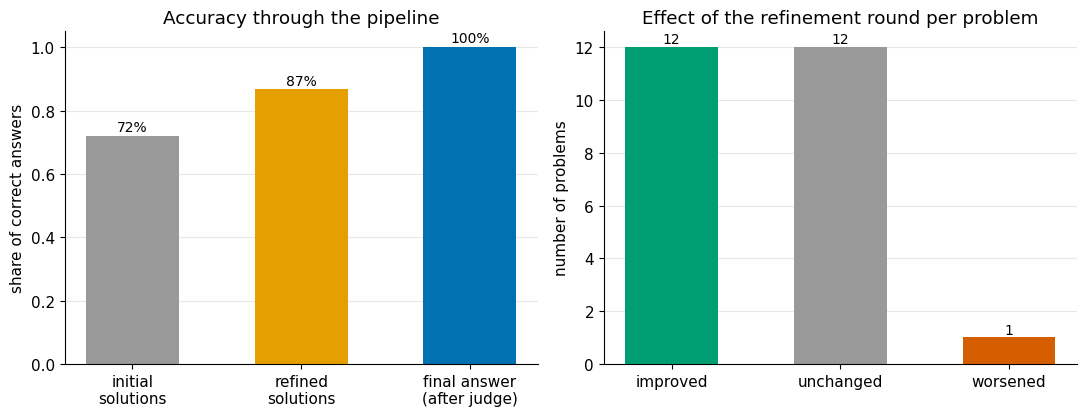

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))

stages = ["initial\nsolutions", "refined\nsolutions", "final answer\n(after judge)"]
stage_vals = [df["n_initial_correct"].mean() / 3, df["n_refined_correct"].mean() / 3, overall_accuracy]
bars = ax1.bar(stages, stage_vals, color=[GRAY, ORANGE, BLUE], width=0.55)
for b, v in zip(bars, stage_vals):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.0%}", ha="center", fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("share of correct answers")
ax1.set_title("Accuracy through the pipeline")

effect_labels = ["improved", "unchanged", "worsened"]
effect_vals = [improved, unchanged, worsened]
bars = ax2.bar(effect_labels, effect_vals, color=[GREEN, GRAY, RED], width=0.55)
for b, v in zip(bars, effect_vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.15, str(v), ha="center", fontsize=10)
ax2.set_ylabel("number of problems")
ax2.set_title("Effect of the refinement round per problem")

fig.tight_layout()
save(fig, "refinement_effect.png")
plt.show()

## Plot 4: role assignment and the judge

Left: which model got picked as judge how often (stage 0.5 output).
Right: how often each model's solution won the debate (among the problems it was a solver in).

saved plots/roles_and_judge.png


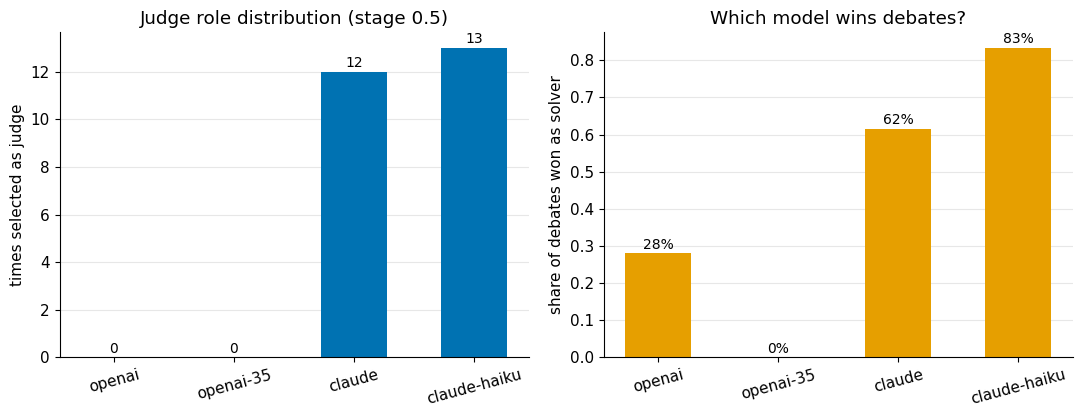

In [31]:
judge_counts = df["judge_model"].value_counts().reindex(AGENTS).fillna(0)
win_counts = df["winner_model"].value_counts().reindex(AGENTS).fillna(0)
solver_counts = pd.Series(
    {m: sum(1 for _, r in results.items() if m in r["solver_models"].values()) for m in AGENTS}
)
win_rate = (win_counts / solver_counts.replace(0, 1)).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))

ax1.bar(judge_counts.index, judge_counts.values, color=BLUE, width=0.55)
for i, v in enumerate(judge_counts.values):
    ax1.text(i, v + 0.2, str(int(v)), ha="center", fontsize=10)
ax1.set_ylabel("times selected as judge")
ax1.set_title("Judge role distribution (stage 0.5)")
ax1.tick_params(axis="x", rotation=15)

ax2.bar(win_rate.index, win_rate.values, color=ORANGE, width=0.55)
for i, v in enumerate(win_rate.values):
    ax2.text(i, v + 0.012, f"{v:.0%}", ha="center", fontsize=10)
ax2.set_ylabel("share of debates won as solver")
ax2.set_title("Which model wins debates?")
ax2.tick_params(axis="x", rotation=15)

fig.tight_layout()
save(fig, "roles_and_judge.png")
plt.show()

## Where did the system still fail?

Quick qualitative look at the problems the debate got wrong - useful for the presentation.

In [32]:
failed = df[~df["final_correct"]]
if len(failed) == 0:
    print("the debate system solved every problem!")
for pid in failed.index:
    r = results[pid]
    print(f"--- {pid} ({r['category']})")
    print(f"    question: {r['question'][:110]}...")
    print(f"    ground truth: {r['ground_truth'][:90]}")
    print(f"    final answer: {r['final_answer'][:90]}")
    print(f"    correct solvers initial/refined: {df.loc[pid,'n_initial_correct']}/{df.loc[pid,'n_refined_correct']}, "
          f"judge picked {r['verdict']['winner']} ({r['solver_models'][r['verdict']['winner']]})")

the debate system solved every problem!


## Conclusions

(numbers are filled in by the cells above, short version for the reader)

- The debate system is compared against 5 baselines on 25 problems from 4 categories
- Peer review + refinement mostly helps weaker solvers fix calculation slips and reconsider traps,
  while correct solvers successfully defend their answers against wrong critiques
- The judge stage matters on the problems where solvers still disagree after refinement -
  this is exactly where majority voting can fail (the majority can be wrong)
- Main takeaway: the ensemble of cheap models with structured debate is competitive with
  (or better than) a single stronger model asked once

In [33]:
print("evaluation done, all plots saved to plots/")

evaluation done, all plots saved to plots/
